<a href="https://colab.research.google.com/github/marcos-mansur/load-forecast/blob/main/Notebook_5_base_em_semanas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Files

In [2]:
df_20XX = pd.read_csv('https://raw.githubusercontent.com/marcos-mansur/load-forecast/main/Data/CARGA_ENERGIA_2020.csv', 
                      sep=';', 
                      parse_dates=['din_instante'])

# Treat data

In [6]:
def treat_data(df,regiao='SUDESTE',operative_week_start=2):
  
  # round the values of load
  df['val_cargaenergiamwmed'] = np.round(df['val_cargaenergiamwmed'],2)
  # drop last 4 rows that doesn't have load values
  df.dropna(axis=0, how='any',inplace=True)
  # filter data by subsystem 
  try:
    df = df[df['nom_subsistema']==regiao].reset_index().drop('index',axis=1).copy()
  except:
    pass
  # dropa colunas sobre região
  df.drop(labels=['nom_subsistema','id_subsistema'], inplace=True, axis=1,errors='ignore')


  # 3 of jan'20 is the first friday of the year- begins the operative week
  df = df[operative_week_start:].copy()
  # create column with week number 
  df.reset_index(inplace=True,drop=True)
  df['semana'] = (df.index)//7 

  mean_load_week = df.groupby(by=['semana'])['val_cargaenergiamwmed'].mean()  
  date_week = df.groupby(by=['semana'])['din_instante'].max()
  df1 = pd.DataFrame(data=mean_load_week)
  # data de inicio da semana prevista
  df1['data'] = date_week
  return df1

df = treat_data(df_20XX,regiao='SUDESTE')
df.head()

,val_cargaenergiamwmed,data
semana,,
0,38496.844286,2020-01-16
1,41465.118571,2020-01-23
2,39106.025714,2020-01-30
3,39745.141429,2020-02-06
4,40919.648571,2020-02-13


In [8]:
df.shape

(52, 2)

# Initialize constants

In [44]:
# 30 days of validation
split_time = int(len(df)*0.7)
batch_size = 32
window_size = 7
shuffle_buffer = 20
np.random.seed(42)

print('split time = ',split_time)

split time =  36


# Visualize data

In [45]:
def plot_serie(df1,col='val_cargaenergiamwmed',start=0,end=None, title=''):
  plt.rcParams['figure.figsize'] = [15,6]
  plt.plot(df1['data'][start:end],
           df1[col][start:end],)
  plt.title(title + col + ', start = '+ str(start) + ', end = ' + str(end))
  plt.xlabel("Time")
  plt.ylabel("Value")
  plt.grid(True)
  return plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.7/dist-packages/matplotlib/pyplot.py'>

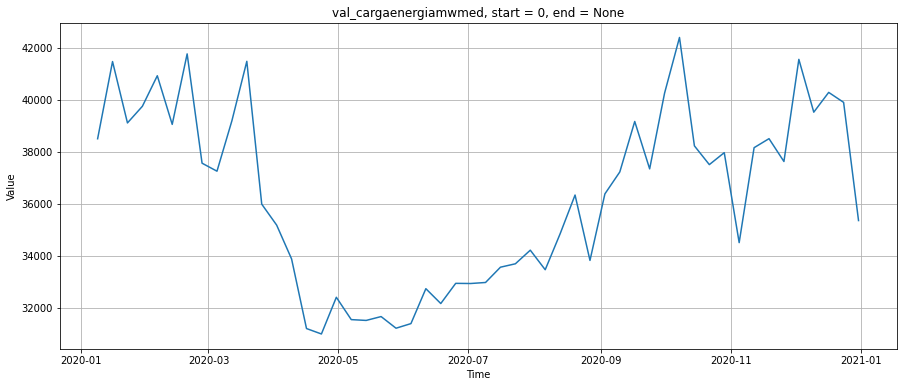

In [46]:
plot_serie(df)

# Split train test

In [47]:
# split_time 
x_train = df[:split_time].copy().reset_index(drop=True)
x_valid = df[split_time:].copy().reset_index(drop=True)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.7/dist-packages/matplotlib/pyplot.py'>

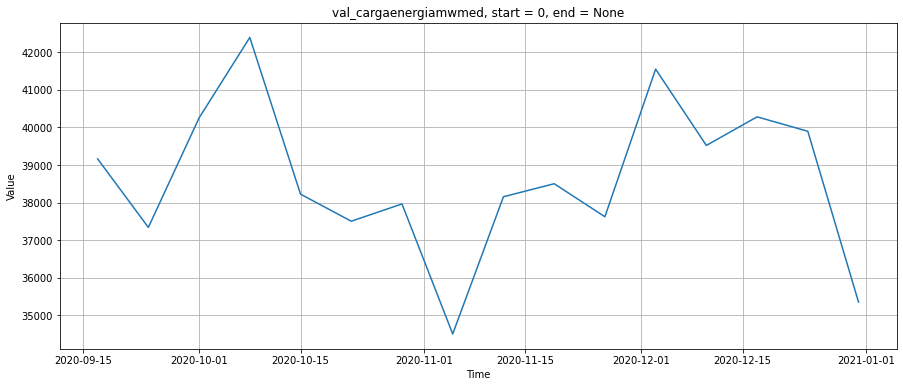

In [48]:
plot_serie(x_valid)

# TensorFlow Dataset

In [54]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
  dataset = tf.data.Dataset.from_tensor_slices(series)
  dataset = dataset.window(window_size + 7, shift=1, drop_remainder=True)
  dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))
  dataset = dataset.shuffle(shuffle_buffer).map(lambda window: (window[:-1], window[-1]))
  dataset = dataset.batch(batch_size).prefetch(1)
  return dataset

dataset = windowed_dataset(x_train['val_cargaenergiamwmed'], window_size, batch_size, shuffle_buffer)

# Train model


In [ ]:
l0 = tf.keras.layers.SimpleRNN(50, return_sequences=False, kernel_initializer='normal')
l1 = tf.keras.layers.SimpleRNN(20, return_sequences=False)
# Sequential NN
model = tf.keras.models.Sequential([
    tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis = -1), input_shape=[None]),
    tf.keras.layers.BatchNormalization(),
    l0,
#    l1,
    tf.keras.layers.Dense(1),
    tf.keras.layers.Lambda(lambda x: x * 10000.0)
    ])

# compile
model.compile(loss="mse", optimizer = 'adam')

# Checkpoint
filepath = 'RNN.hdf5'
checkpoint = ModelCheckpoint(filepath, monitor = 'loss', verbose = 1, save_best_only = True, mode = 'min')
callbacks_list = [checkpoint]

# train the NN
history = model.fit(dataset,epochs=160,verbose=0, callbacks=callbacks_list)

print(os.listdir())

print("Layer weights {}".format(l0.get_weights()))

Layer weights [array([[-0.02788972, -0.05558141, -0.01283968, -0.06725491,  0.00255061,
        -0.02127625,  0.07582283, -0.05875356, -0.04802172,  0.00589212,
        -0.04542726,  0.06025318, -0.00272287,  0.07210135, -0.02043039,
         0.11644064, -0.12376414, -0.05128385, -0.0122061 , -0.00667792,
         0.00098295,  0.01005524, -0.02819254,  0.02584311, -0.07788908,
        -0.03490074,  0.00059187,  0.09636386,  0.13612114,  0.04396808,
        -0.07814904, -0.02510118,  0.03772242,  0.03520675, -0.10324296,
        -0.00632417, -0.0335227 , -0.03746059, -0.00785886, -0.00600787,
        -0.03902318,  0.01323209,  0.0576688 ,  0.02447388,  0.00271016,
        -0.06860913, -0.07725711, -0.0208545 ,  0.02567245,  0.01906238]],
      dtype=float32), array([[-0.02246051, -0.0563303 ,  0.17719361, ...,  0.27174696,
        -0.12115306,  0.08426586],
       [ 0.15296325, -0.00168196, -0.16349371, ...,  0.07928035,
         0.19274427,  0.228104  ],
       [-0.08967737, -0.2106318

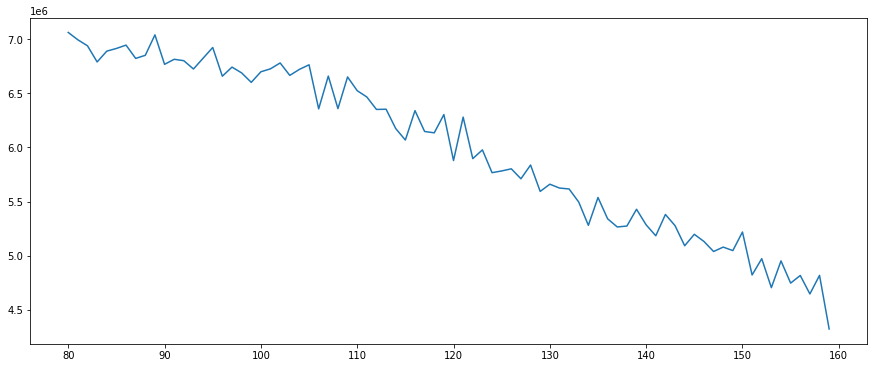

In [ ]:
skip = 80
plt.plot(range(skip,len(history.history['loss'])),history.history['loss'][skip:])
#plt.plot(range(skip,len(history.history['mse'])),history.history['mse'][skip:])


# Prediction

In [ ]:
forecast = []
for time in range(len(df) - window_size):
  forecast.append(model.predict(np.array(df['val_cargaenergiamwmed'][time:time + window_size])[np.newaxis]))

valid_forecast = forecast[split_time-window_size:]
results = np.array(valid_forecast)[:, 0, 0]

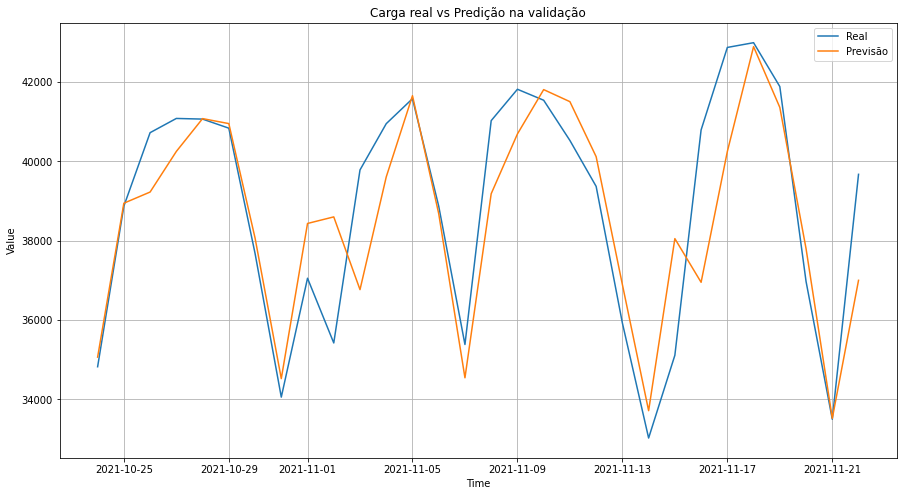

In [ ]:
plt.figure(figsize=(15, 8))

plot_serie(x_valid)
plt.plot(x_valid.din_instante, results)
plt.title('Carga real vs Predição na validação')
plt.legend(['Real', 'Previsão'])

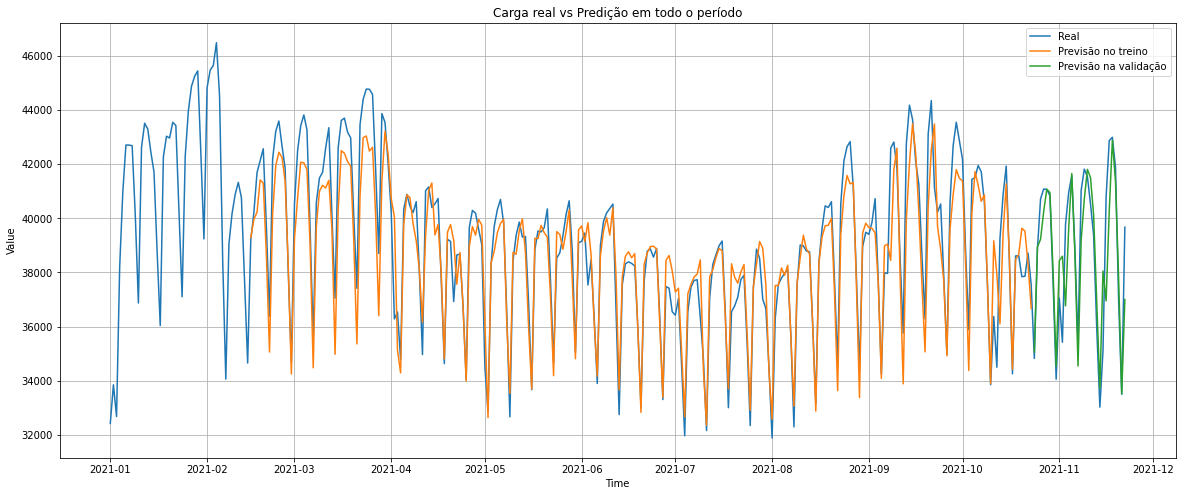

In [ ]:
plt.figure(figsize=(20, 8))

plot_serie(df)
plt.plot(df.din_instante[window_size:split_time], np.array(forecast)[:split_time-window_size,0,0])
plt.plot(df.din_instante[split_time:],np.array(forecast)[split_time-window_size:,0,0])
plt.title('Carga real vs Predição em todo o período')
plt.legend(['Real', 'Previsão no treino', 'Previsão na validação'])

In [ ]:
print('MAE on train: ',
      tf.keras.metrics.mean_absolute_error(
          np.array(df.val_cargaenergiamwmed[window_size:split_time]), 
          np.array(forecast)[:split_time-window_size,0,0]).numpy()
          )

print('MAE on validation: ',
      tf.keras.metrics.mean_absolute_error(
          np.array(x_valid['val_cargaenergiamwmed']), 
          results).numpy()
          )

MAE on train:  817.8983
MAE on validation:  1128.096
